## **Layer 3 Decision & Policy Layer**

In [11]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_ta as ta

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

current_working_dir = os.getcwd()
if os.path.basename(current_working_dir) == "layers":
    PROJECT_ROOT = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    PROJECT_ROOT = current_working_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define data path
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
# Load the data that now includes signals
SIGNALS_DATA_FILE = os.path.join(DATA_DIR, "market_data_signals.parquet")

print(f"Project root set to: {PROJECT_ROOT}")
print(f"Loading data with signals from: {SIGNALS_DATA_FILE}")

try:
    # Load the data processed by Layer 1 and Layer 2
    df = pd.read_parquet(SIGNALS_DATA_FILE)
    print("Successfully loaded data with signals.")
except FileNotFoundError:
    print("Error: Data file 'market_data_signals.parquet' not found.")
    print("Please ensure Layer 1 and Layer 2 notebooks have been run and saved the data.")
    df = pd.DataFrame()

if not df.empty:
    print("\nVerifying required columns ('regime', 'signal'):")
    print(df[['datetime', 'close', 'regime', 'signal']].head())

Project root set to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Loading data with signals from: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_data_signals.parquet
Successfully loaded data with signals.

Verifying required columns ('regime', 'signal'):
                   datetime       close                  regime   signal
0 2026-01-29 14:43:00+00:00  190.270004                 Unknown  Neutral
1 2026-01-29 14:44:00+00:00  190.610001  Ranging - Accumulation  Neutral
2 2026-01-29 14:45:00+00:00  190.919998  Ranging - Accumulation  Neutral
3 2026-01-29 14:46:00+00:00  190.774994  Ranging - Accumulation  Neutral
4 2026-01-29 14:47:00+00:00  191.369904  Ranging - Accumulation  Neutral


## **Backtest Simulation**

### **Letting Winners Run : Trailing Stop-Loss**
The New Solution: We replaced the simple signal-based exit with a **dynamic Trailing Stop-Loss**
  - **How it Works** : When you enter a trade (e.g., at $260 with a 1% trailing stop), the initial stop-loss is set at $257.40. If the stock price rises to a new high of $265, your stop-loss automatically moves up to $262.35 (1% below the new peak)
  
  - **The Impact on Profit** : This is the key to capturing large trends. The bot now stays in a winning trade for as long as it keeps making new highs. It only sells when the trend finally reverses and the price drops by our specified percentage from its peak, locking in a much larger profit than before.


### **Descriptive Signals**
The Old Problem: The generic 'Bullish' and 'Bearish' signals were causing confusion. A 'Bearish' signal could mean "exit a long trade" or "enter a short trade," leading to misaligned logic and too many unnecessary trades.

* **The New Solution** : We created more descriptive signals to separate the reason for the action.
  * `'Enter Long'`: This signal is now generated only for high-probability entry setups, like an 'Uptrend - Pullback' or 'Ranging - Accumulation'. The bot no longer tries to buy on every minor sign of bullishness.
  
  * `'Exit Long'`: This signal is now generated specifically when an uptrend shows signs of weakness or reversal (e.g., the regime becomes 'Uptrend - Overbought' or 'Downtrend - Impulse').

* **The Impact on Profit** : This clear separation between entry and exit logic makes
  the bot's decisions much more deliberate. It reduces the number of low-quality
  trades taken in uncertain conditions, which helps prevent the "death by a
  thousand cuts" from small, repeated losses.

In [12]:
if not df.empty:
    # --- Backtest Configuration (Dynamic Sizing) ---
    initial_capital = 100000.0
    RISK_PER_TRADE_PERCENTAGE = 0.01 
    MAX_INVESTMENT_PER_TRADE_PERCENTAGE = 0.25
    ATR_MULTIPLIER = 2.0
    TAKE_PROFIT_ATR_MULTIPLIER = 3.0

    # --- State Tracking & Logging ---
    df['position_shares'] = 0.0
    df['cash'] = initial_capital
    df['portfolio_value'] = initial_capital
    trades_log = [] 

    # --- Per-Trade State Variables (outside loop) ---
    shares_in_position = 0.0
    buy_price_per_share = 0.0
    highest_price_since_buy = 0.0
    entry_atr = 0.0

    # Ensure 'signal_confidence' exists. If not, create a placeholder for compatibility.
    if 'signal_confidence' not in df.columns:
        print("Warning: 'signal_confidence' column not found. Defaulting to 1.0.")
        df['signal_confidence'] = 1.0

    # --- Simulation Loop ---
    for i in range(1, len(df)):
        # Carry over previous state
        df.loc[i, 'cash'] = df.loc[i-1, 'cash']
        df.loc[i, 'position_shares'] = df.loc[i-1, 'position_shares']
        df.loc[i, 'portfolio_value'] = df.loc[i-1, 'portfolio_value']

        current_close_price = df.loc[i, 'close']
        signal = df.loc[i, 'signal']

        # Get ATR for current bar
        current_atr = df.loc[i, 'ATR_14'] if pd.notna(df.loc[i, 'ATR_14']) else 0.0

        # --- LOGIC WHEN IN A POSITION ---
        if shares_in_position > 0:
            # Update the highest price seen so far in this trade
            highest_price_since_buy = max(highest_price_since_buy, current_close_price)
            # Update the trailing stop-loss price using ATR
            trailing_stop_price = highest_price_since_buy - (current_atr * ATR_MULTIPLIER)

            # Calculate Dynamic Take Profit Price based on entry ATR
            take_profit_price = buy_price_per_share + (entry_atr * TAKE_PROFIT_ATR_MULTIPLIER)

            # --- Check for exit conditions ---
            is_take_profit_hit = current_close_price >= take_profit_price
            is_trailing_stop_hit = current_close_price <= trailing_stop_price
            is_signal_exit = signal == 'Exit Long'

            if is_take_profit_hit or is_trailing_stop_hit or is_signal_exit:
                exit_type = ''
                if is_take_profit_hit: exit_type = 'SELL (TP)'
                elif is_trailing_stop_hit: exit_type = 'SELL (Trail SL)'
                elif is_signal_exit: exit_type = 'SELL (Signal)'

                # Execute the sell
                pnl_dollars = (current_close_price - buy_price_per_share) * shares_in_position
                df.loc[i, 'cash'] += current_close_price * shares_in_position
                df.loc[i, 'position_shares'] = 0

                trades_log.append({
                    'Type': exit_type, 
                    'Entry Price': buy_price_per_share,
                    'Exit Date': df.loc[i, 'datetime'], 
                    'Exit Price': current_close_price,
                    'Quantity': shares_in_position, 
                    'P/L ($)': pnl_dollars,
                    'Signal': signal if exit_type == 'SELL (Signal)' else exit_type,
                    'Regime': df.loc[i, 'regime']
                })
                # Reset all per-trade state variables
                shares_in_position, buy_price_per_share, highest_price_since_buy, entry_atr = 0.0, 0.0, 0.0, 0.0

        # --- LOGIC WHEN NOT IN A POSITION ---
        elif shares_in_position == 0:
            # Check for an entry signal
            if signal == 'Enter Long':
                confidence = df.loc[i, 'signal_confidence']
                stop_loss_distance_per_share = current_atr * ATR_MULTIPLIER

                if stop_loss_distance_per_share > 0:
                    current_portfolio_value = df.loc[i-1, 'portfolio_value']

                    # 1. Calculate position size based on risk, scaled by confidence
                    dollar_amount_to_risk = current_portfolio_value * RISK_PER_TRADE_PERCENTAGE * confidence
                    num_shares_based_on_risk = np.floor(dollar_amount_to_risk / stop_loss_distance_per_share)
                    
                    # 2. Calculate position size based on max investment cap
                    max_investment_dollars = current_portfolio_value * MAX_INVESTMENT_PER_TRADE_PERCENTAGE
                    num_shares_based_on_max_investment = np.floor(max_investment_dollars / current_close_price)

                    # 3. Use the smaller of the two position sizes
                    num_shares_to_buy = min(num_shares_based_on_risk, num_shares_based_on_max_investment)
                    
                    trade_cost = num_shares_to_buy * current_close_price
                    
                    if num_shares_to_buy > 0 and df.loc[i, 'cash'] >= trade_cost:
                        # Execute the buy
                        df.loc[i, 'position_shares'] = num_shares_to_buy
                        df.loc[i, 'cash'] -= trade_cost

                        # Set the state for the new trade
                        buy_price_per_share = current_close_price 
                        shares_in_position = num_shares_to_buy
                        highest_price_since_buy = current_close_price
                        entry_atr = current_atr # Store ATR on entry

                        trades_log.append({
                            'Type': 'BUY', 
                            'Entry Date': df.loc[i, 'datetime'],
                            'Entry Price': current_close_price, 
                            'Quantity': num_shares_to_buy
                        })

        # --- Daily Portfolio Valuation (End of Day) ---
        df.loc[i, 'portfolio_value'] = df.loc[i, 'cash'] + (df.loc[i, 'position_shares'] * current_close_price)

    print("Backtest simulation complete.")

    # --- Process Transaction Log for Display ---
    processed_trades_log = []
    open_trade = {}
    for trade_event in trades_log:
        if trade_event['Type'] == 'BUY':
            open_trade = trade_event.copy()
        elif 'SELL' in trade_event['Type'] and open_trade:
            # Combine buy and sell info
            sell_trade = {**open_trade, **trade_event} 

            # Recalculate P/L percent after combining
            pnl_dollars_combined = (sell_trade['Exit Price'] - sell_trade['Entry Price']) * sell_trade['Quantity']
            total_cost = sell_trade['Entry Price'] * sell_trade['Quantity']
            pnl_percent_combined = (pnl_dollars_combined / total_cost) * 100 if total_cost > 0 else 0

            sell_trade['P/L ($)'] = pnl_dollars_combined
            sell_trade['P/L (%)'] = pnl_percent_combined

            processed_trades_log.append(sell_trade)
            open_trade = {} # Reset for next trade

    trades_df_final = pd.DataFrame(processed_trades_log)

    print("\n--- Transaction by Transaction Overview ---")
    if not trades_df_final.empty:
        display_cols = ['Entry Date', 'Entry Price', 'Exit Date', 'Exit Price', 'Quantity', 'P/L ($)', 'P/L (%)', 'Type', 'Signal', 'Regime']
        trades_df_display = trades_df_final[display_cols].copy()
        for col in ['Entry Price', 'Exit Price', 'P/L ($)']:
            trades_df_display[col] = trades_df_display[col].map('${:,.2f}'.format)
        trades_df_display['P/L (%)'] = trades_df_display['P/L (%)'].map('{:.2f}%'.format)
        print(trades_df_display.to_string())
    else:
        print("No completed (Buy then Sell) trades were executed.")

else:
    print("DataFrame is empty, cannot run backtest.")

Backtest simulation complete.

--- Transaction by Transaction Overview ---
                  Entry Date Entry Price                 Exit Date Exit Price  Quantity   P/L ($) P/L (%)             Type           Signal                    Regime
0  2026-01-29 15:30:00+00:00     $188.83 2026-01-29 15:36:00+00:00    $188.00     132.0  $-109.56  -0.44%  SELL (Trail SL)  SELL (Trail SL)  Ranging - Downtrend Bias
1  2026-01-29 16:04:00+00:00     $186.31 2026-01-29 16:05:00+00:00    $186.49     134.0    $24.12   0.10%    SELL (Signal)        Exit Long         Volatile - Choppy
2  2026-01-29 16:07:00+00:00     $186.11 2026-01-29 16:09:00+00:00    $186.36     134.0    $33.50   0.13%    SELL (Signal)        Exit Long         Volatile - Choppy
3  2026-01-29 16:49:00+00:00     $188.07 2026-01-29 17:02:00+00:00    $188.45     132.0    $49.50   0.20%    SELL (Signal)        Exit Long       Downtrend - Impulse
4  2026-01-29 17:43:00+00:00     $189.57 2026-01-29 17:53:00+00:00    $189.37     131.0   $-27.

## **Performance Analysis and Visualization**


--- Backtest Performance Metrics ---
Initial Capital:          $100,000.00
Final Portfolio Value:    $100,180.47
Strategy Total Return:    0.18%
Buy & Hold Total Return:  1.14%
Maximum Drawdown:         -0.11%


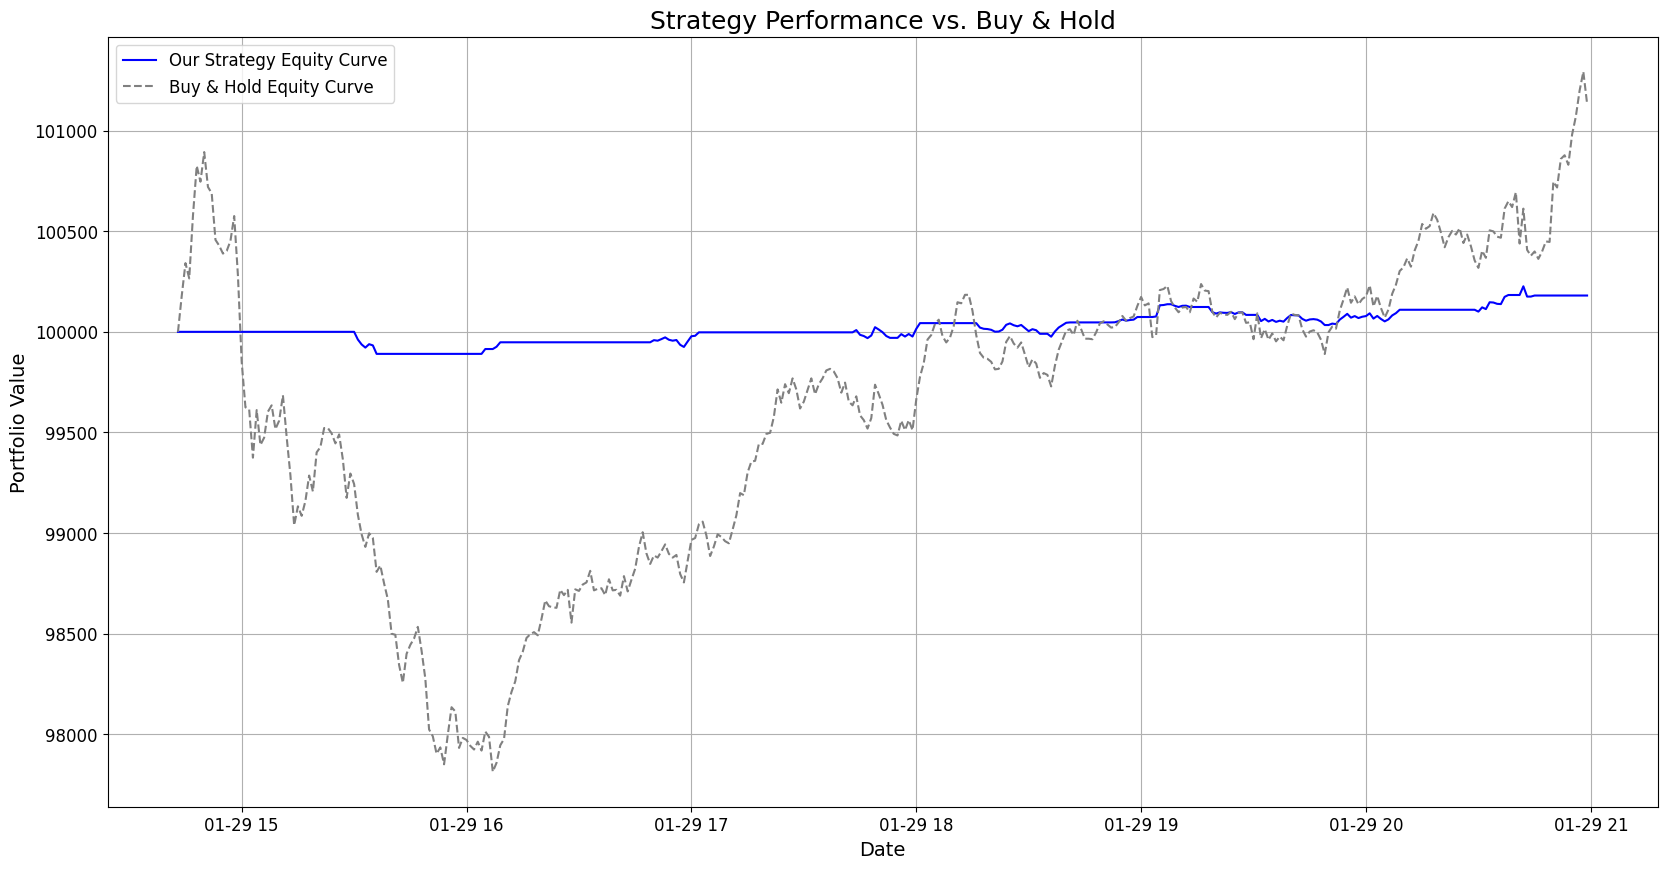

In [13]:
if not df.empty:
    # --- Performance Metrics (Layer 4) ---
    final_portfolio_value = df['portfolio_value'].iloc[-1]
    total_return_pct = ((final_portfolio_value / initial_capital) - 1) * 100
    
    # Calculate Buy & Hold return for comparison
    buy_hold_return_pct = ((df['close'].iloc[-1] / df['close'].iloc[0]) - 1) * 100
    
    # Calculate Max Drawdown (critical risk metric)
    rolling_max = df['portfolio_value'].cummax()  # Get the running maximum
    daily_drawdown = df['portfolio_value'] / rolling_max - 1.0  # Calculate daily drawdown
    max_drawdown_pct = daily_drawdown.min() * 100  # Find the largest drawdown

    print("\n--- Backtest Performance Metrics ---")
    print(f"Initial Capital:          ${initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ${final_portfolio_value:,.2f}")
    print(f"Strategy Total Return:    {total_return_pct:.2f}%")
    print(f"Buy & Hold Total Return:  {buy_hold_return_pct:.2f}%")
    print(f"Maximum Drawdown:         {max_drawdown_pct:.2f}%")
    
    # --- Visualization ---
    plt.figure(figsize=(20, 10))
    
    # Plot our strategy's equity curve
    plt.plot(df['datetime'], df['portfolio_value'], label='Our Strategy Equity Curve', color='blue')
    
    # Plot Buy & Hold equity curve for comparison
    buy_hold_equity = (df['close'] / df['close'].iloc[0]) * initial_capital
    plt.plot(df['datetime'], buy_hold_equity, label='Buy & Hold Equity Curve', color='gray', linestyle='--')
    
    plt.title('Strategy Performance vs. Buy & Hold', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True)
    plt.show()


--- Backtest Performance Metrics ---
Initial Capital:           $100,000.00
Final Portfolio Value:     $100,180.47
Strategy Total Return:     0.18%
Buy & Hold Total Return:   1.14%
Maximum Drawdown:          -0.11%


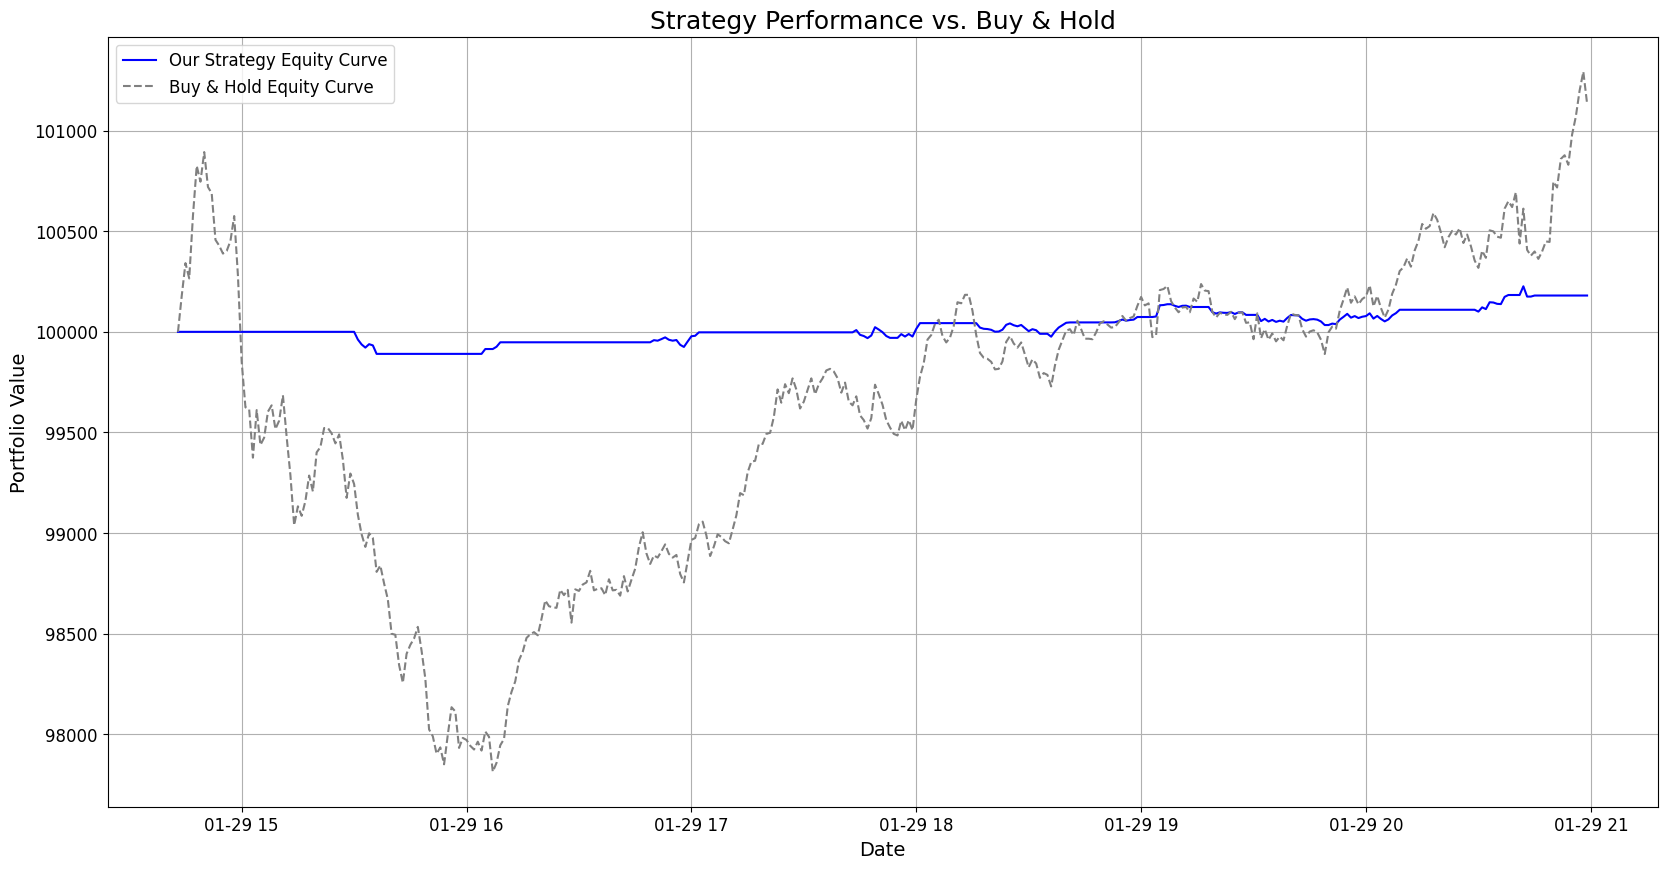


--- Trading Activity Summary ---
Number of Buy Trades: 17
Number of Sell Trades: 17
Total Trades: 34


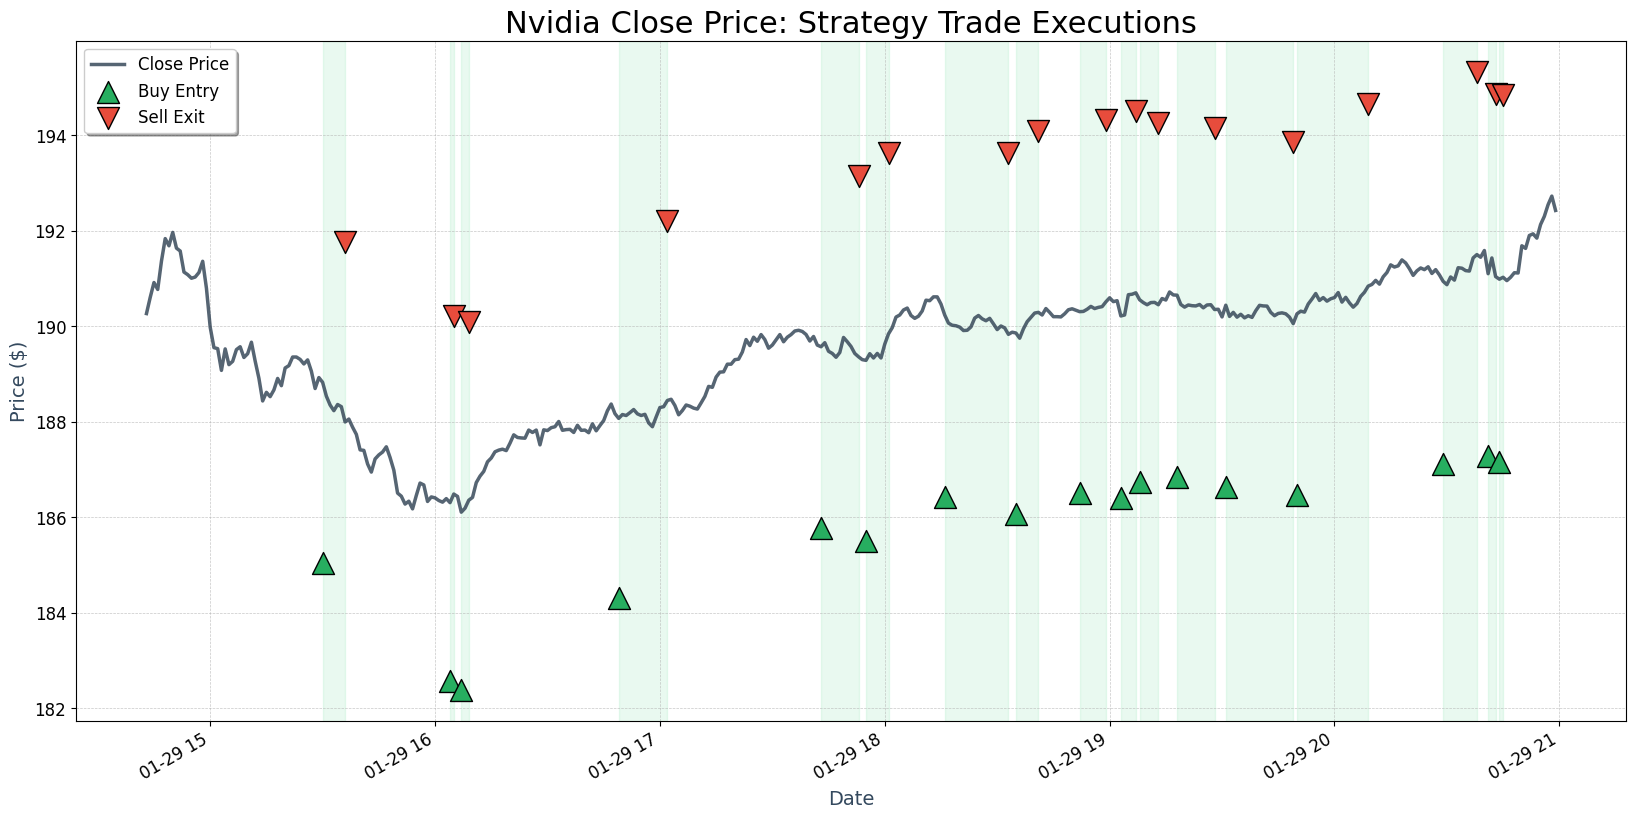

In [14]:
if not df.empty:
    # --- Performance Metrics ---
    final_portfolio_value = df['portfolio_value'].iloc[-1]
    total_return_pct = ((final_portfolio_value / initial_capital) - 1) * 100
    
    buy_hold_return_pct = ((df['close'].iloc[-1] / df['close'].iloc[0]) - 1) * 100
    
    rolling_max = df['portfolio_value'].cummax()
    daily_drawdown = df['portfolio_value'] / rolling_max - 1.0
    max_drawdown_pct = daily_drawdown.min() * 100

    print("\n--- Backtest Performance Metrics ---")
    print(f"Initial Capital:           ${initial_capital:,.2f}")
    print(f"Final Portfolio Value:     ${final_portfolio_value:,.2f}")
    print(f"Strategy Total Return:     {total_return_pct:.2f}%")
    print(f"Buy & Hold Total Return:   {buy_hold_return_pct:.2f}%")
    print(f"Maximum Drawdown:          {max_drawdown_pct:.2f}%")
    
    # --- Equity Curve Visualization ---
    plt.figure(figsize=(20, 10))
    plt.plot(df['datetime'], df['portfolio_value'], label='Our Strategy Equity Curve', color='blue')
    
    buy_hold_equity = (df['close'] / df['close'].iloc[0]) * initial_capital
    plt.plot(df['datetime'], buy_hold_equity, label='Buy & Hold Equity Curve', color='gray', linestyle='--')
    
    plt.title('Strategy Performance vs. Buy & Hold', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True)
    plt.show()

    # --- Trading Activity Summary ---
    # Logic to identify transition points where shares were bought or sold
    num_buys = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)].shape[0]
    num_sells = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)].shape[0]
    
    print("\n--- Trading Activity Summary ---")
    print(f"Number of Buy Trades: {num_buys}")
    print(f"Number of Sell Trades: {num_sells}")
    print(f"Total Trades: {num_buys + num_sells}")

    # --- Trade Visualization on Price Chart ---
    plt.figure(figsize=(20, 10))
    
    # Plot the Close Price with a sleek dark line
    plt.plot(df['datetime'], df['close'], label='Close Price', color='#2c3e50', linewidth=2.5, alpha=0.8)
    
    # Mark Buy Signals: Using a larger 'up' arrow with a black edge
    buy_signals = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)]
    plt.scatter(buy_signals['datetime'], buy_signals['close'] * 0.98, # Offset slightly below price
                marker='^', color='#27ae60', s=250, label='Buy Entry', 
                edgecolors='black', linewidths=1, zorder=5)
    
    # Mark Sell Signals: Using a larger 'down' arrow with a black edge
    sell_signals = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)]
    plt.scatter(sell_signals['datetime'], sell_signals['close'] * 1.02, # Offset slightly above price
                marker='v', color='#e74c3c', s=250, label='Sell Exit', 
                edgecolors='black', linewidths=1, zorder=5)
    
    # Optional: Add vertical lines to connect the trade points
    for buy_date, sell_date in zip(buy_signals['datetime'], sell_signals['datetime']):
        plt.axvspan(buy_date, sell_date, color='#2ecc71', alpha=0.1) # Soft green background for trade duration

    # Refined Styling
    plt.title('Nvidia Close Price: Strategy Trade Executions', fontsize=22)
    plt.xlabel('Date', fontsize=14, color='#34495e')
    plt.ylabel('Price ($)', fontsize=14, color='#34495e')
    
    # Legend with a frame
    plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.gcf().autofmt_xdate()
    plt.show()

else:
    print("DataFrame is empty, cannot perform analysis or visualizations.")

In [15]:
num_buys = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)].shape[0]
num_sells = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)].shape[0]

print("\n--- Trading Activity Summary ---")
print(f"Number of Buy Trades: {num_buys}")
print(f"Number of Sell Trades: {num_sells}")
print(f"Total Trades: {num_buys + num_sells}")


--- Trading Activity Summary ---
Number of Buy Trades: 17
Number of Sell Trades: 17
Total Trades: 34
